In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
path = "../data/raw/german.data"

df = pd.read_csv(path, sep=" ", header=None)


In [57]:
columns = [
"checking_account_status",
"duration_months",
"credit_history",
"purpose",
"credit_amount",
"savings_account",
"employment_years",
"installment_rate",
"personal_status_sex",
"other_debtors",
"residence_years",
"property",
"age",
"other_installment_plans",
"housing",
"existing_credits",
"job",
"people_liable",
"telephone",
"foreign_worker",
"credit_risk"
]

df.columns = columns

In [70]:
df["credit_risk"] = df["credit_risk"].map({1:0, 2:1})

In [ ]:
# credit_risk:
# 0 = bom pagador
# 1 = mau pagador (inadimplente)

In [58]:
df.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_years,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [59]:
df.shape

(1000, 21)

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  1000 non-null   str  
 1   duration_months          1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment_years         1000 non-null   str  
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  residence_years          1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

In [61]:
df.describe()

,duration_months,credit_amount,installment_rate,residence_years,age,existing_credits,people_liable,credit_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,1.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,2.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [71]:
df["credit_risk"].value_counts()

credit_risk
0    700
1    300
Name: count, dtype: int64

In [72]:
df["credit_risk"].value_counts(normalize=True)

credit_risk
0    0.7
1    0.3
Name: proportion, dtype: float64

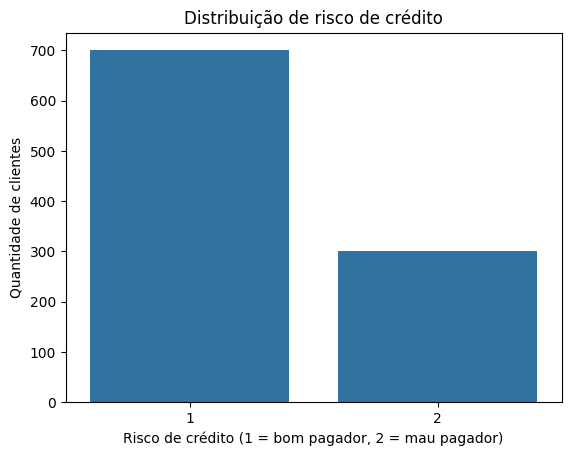

In [64]:
sns.countplot(x="credit_risk", data=df)

plt.title("Distribuição de risco de crédito")
plt.xlabel("Risco de crédito (1 = bom pagador, 2 = mau pagador)")
plt.ylabel("Quantidade de clientes")

plt.show()

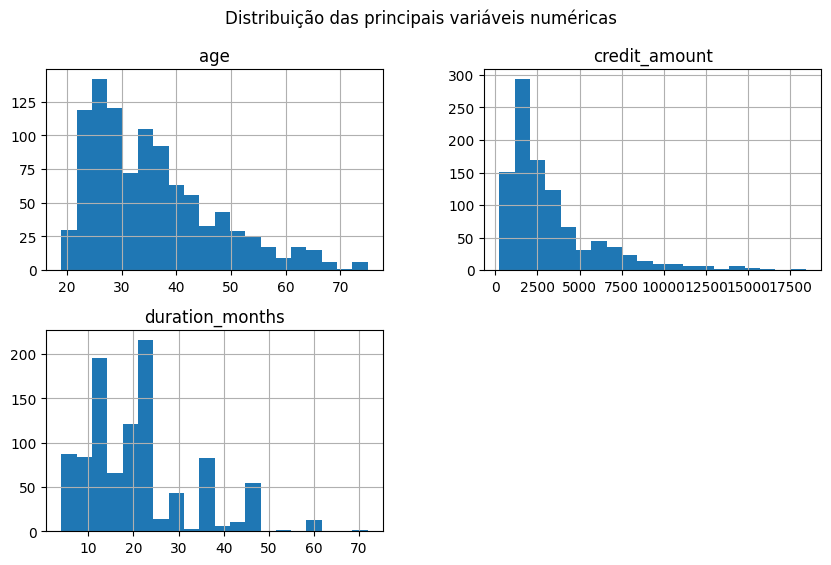

In [65]:
df[["age", "credit_amount", "duration_months"]].hist(bins=20, figsize=(10,6))

plt.suptitle("Distribuição das principais variáveis numéricas")

plt.show()

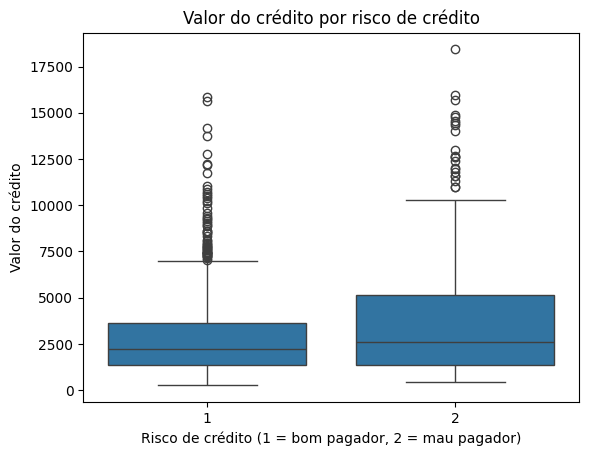

In [66]:
sns.boxplot(x="credit_risk", y="credit_amount", data=df)

plt.title("Valor do crédito por risco de crédito")
plt.xlabel("Risco de crédito (1 = bom pagador, 2 = mau pagador)")
plt.ylabel("Valor do crédito")

plt.show()

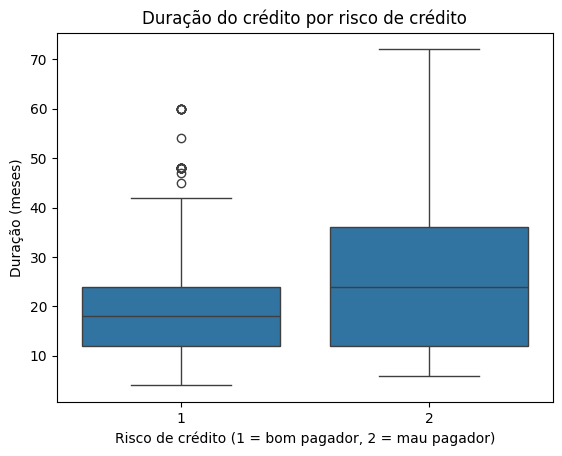

In [67]:
sns.boxplot(x="credit_risk", y="duration_months", data=df)

plt.title("Duração do crédito por risco de crédito")
plt.xlabel("Risco de crédito (1 = bom pagador, 2 = mau pagador)")
plt.ylabel("Duração (meses)")

plt.show()

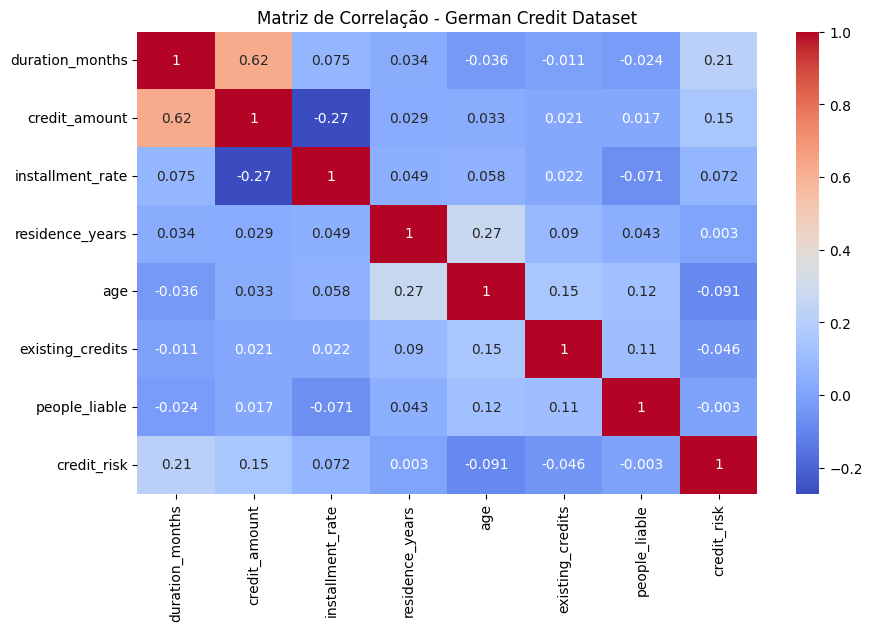

In [73]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Matriz de Correlação - German Credit Dataset")

plt.show()

In [74]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [75]:
df_encoded.shape

(1000, 49)

In [76]:
df_encoded.head()

,duration_months,credit_amount,installment_rate,residence_years,age,existing_credits,people_liable,credit_risk,checking_account_status_A12,checking_account_status_A13,...,property_A124,other_installment_plans_A142,other_installment_plans_A143,housing_A152,housing_A153,job_A172,job_A173,job_A174,telephone_A192,foreign_worker_A202
0,6,1169,4,4,67,2,1,0,False,False,...,False,False,True,True,False,False,True,False,True,False
1,48,5951,2,2,22,1,1,1,True,False,...,False,False,True,True,False,False,True,False,False,False
2,12,2096,2,3,49,1,2,0,False,False,...,False,False,True,True,False,True,False,False,False,False
3,42,7882,2,4,45,1,2,0,False,False,...,False,False,True,False,True,False,True,False,False,False
4,24,4870,3,4,53,2,2,1,False,False,...,True,False,True,False,True,False,True,False,False,False


In [77]:
X = df_encoded.drop("credit_risk", axis=1)
y = df_encoded["credit_risk"]

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [81]:
print(X_train.shape)
print(X_test.shape)

(800, 48)
(200, 48)
